## Part 1: 

*Code a function (subroutine) that generates the BA model for an arbitrary value of N
and m. To store the network structure, it is useful to use and adjacency list, that is, a
1
list of lists that associates to each node a list with its nearest neighbors. Instead of a list
of lists, a dictionary can be used, that for each key, corresponding to the index of each
node, assigns as value the list of its nearest neighbors. Lists are useful since they can
grow in the process of generating the BA network. For the generating process, one needs
to select old nodes with probability Eq. (1) to connect the newly added nodes. Sampling
from such changing distribution can be done using an auxiliary list to select the vertices to
which new edges are attached. Add to this array the number i, every time you add a new
connection to vertex i, and m times the number j whenever you add the new vertex j.
Any number i will appear in this way ki times. Selecting uniformly at random an element
in this auxiliary array will give you the number i with probability proportional to ki. Do
not forget the initial nucleus of the network. You can use the random number generator
provided by Python (the high-quality Mersenne-Twister)*

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

### FUNCTION: `Generate BA Network`

In [3]:
def generate_BA(N,m):
    
    # Initialize Library
    Network = {node: [] for node in range(N)}



    # Initial nucleus size
    n0 = m + 1

    # Connect every node in the nucleus to each other
    for node1 in range(n0):
            for node2 in range(node1 + 1 , n0):  # More efficient than adding (if node1 != node2) loop
                Network[node1].append(node2)
                Network[node2].append(node1)

    # Debug 
    # print(Network)

    # Initialize Aux. list
    aux_list = []

    # Initialize initial nucleus nodes
    for node in range(n0):
        for i in range(len(Network[node])):
            aux_list.append(node)

    # Debug
    # print(aux_list)


    # Add new nodes from n0 to N (where j is the new node)
    for j in range(n0, N):

        connected_nodes = []
        while len(connected_nodes) < m:
            # Randomly select attachment node
            the_chosen_node = np.random.choice(aux_list)
            if the_chosen_node not in connected_nodes:
                connected_nodes.append(the_chosen_node)

                # Append 'the_chosen_node' at the index 'new_node' in Network
                # Connect the two using the same method as the initial nucleus
                Network[j].append(the_chosen_node)
                Network[the_chosen_node].append(j)


        # Add number i to each connection made
        for i in connected_nodes:
            aux_list.append(i)

        # Add the new node, j * m for each new vertex i
        aux_list.extend([j] * m)  
        
    return Network

### FUNCTION: `Degree Distribution`

We create another function to plot the degree distribution that returns `k_list` which is a list of the degrees with the index being the node.

In [4]:
def create_degree_list(Network, m):

    k_list = []
    mf_approx_list = []

    for node in Network:
        k = len(Network[node])
        k_list.append(k)

        # Mean Field Approx (Extra)
        mf_approx = (2*(m^2)) / (k^3)
        mf_approx_list.append(mf_approx)



    # Step 1: Plot the degree distribution as a histogram

    # plt.figure(figsize=(8, 6))
    # plt.hist(k_list, bins=range(min(k_list), max(k_list) + 2), edgecolor='black', alpha=0.7, label='Degree Distribution')
    # plt.xlabel('Degree (k)')
    # plt.ylabel('Frequency')
    # plt.title(f'Degree Frequency Distribution\nNetwork Size: {N}')
    # plt.legend()
    # plt.show()

    return k_list

### FUNCTION: `Plot Probabilities`
Plot Equations 3 and 4 Against Degree Distribution

In [26]:
def plot_probabilities(k_list, N, m):
    # Incorporate Eq. (3) and (4)

    # To handle floats in arrays
    k_list = np.array(k_list)
    degree = np.linspace(k_list.min(), k_list.max(), num=100)  

    # Compute P_inf for each degree k in degree
    P_inf = []
    P_N = []
    for k in degree:
    
        # Compute P_inf (Equation 3)
        P_inf_i = (2 * m * (m + 1)) / (k * (k + 1) * (k + 2))
        P_inf.append(P_inf_i)

        # Compute P_N (Equation 4)
        P_N_i = P_inf_i * (k / np.sqrt(N))
        P_N.append(P_N_i)
    

    # Plot Probability with Frequency Distribution (Normalized)
    # P_inf
    plt.figure()
    plt.plot(degree, P_inf, label="P_inf(k)", linewidth=3)
    plt.xlabel("k")
    plt.ylabel("P_inf")
    plt.grid(True)
    plt.legend()

    # P_N
    plt.plot(degree, P_N, label="P_N(k)", linewidth=3)
    plt.xlabel("k")
    plt.ylabel("P_N")
    plt.grid(True)
    plt.legend()

    return P_inf





### FUNCTION: `Plot Averaged Probablilites`
This is to account for all the averaged probabilities. Returns P_inf and P_N

In [27]:
def plot_averaged_probabilities(hist_avg, bins, N, m):
    
    
    # Degree array
    degree = np.array(bins[:-1])

    
    # Find the first non-zero bin in the hist_avg
    first_non_zero_index = np.argmax(hist_avg > 0)
    # first_non_zero_degree = degree[first_non_zero_index]

    # Find first non-zero degree to start Probability calculation at
    trimmed_degree = degree[first_non_zero_index:]
    # trimmed_hist_avg = hist_avg[first_non_zero_index:]

    # Compute trimmed P_inf and P_N
    P_inf = []
    P_N = []
    
    for k in trimmed_degree:
        if k > 0:  # Avoid division by zero for k = 0
            # Compute P_inf (Equation 3)
            P_inf_i = (2 * m * (m + 1)) / (k * (k + 1) * (k + 2))
            P_inf.append(P_inf_i)

            # Compute P_N (Equation 4)
            P_N_i = P_inf_i * (k / np.sqrt(N))
            P_N.append(P_N_i)
        else:
            P_inf.append(0)
            P_N.append(0)

    
    # Plot P_inf and P_N
    plt.figure()
    plt.plot(trimmed_degree, P_inf, label="P_inf(k)", linewidth=3)
    plt.plot(trimmed_degree, P_N, label="P_N(k)", linewidth=3)
    
    plt.xlabel("k (Degree)")
    plt.ylabel("Probability")
    plt.legend()
    plt.grid(True)
    
    ## Optional Axis Limits
    # plt.xlim(trimmed_degree[0], trimmed_degree[-1])

    


### FUNCTION: `Compute P_inf`

In [7]:
def compute_p_inf(hist_avg, bins, m):

    degree = np.array(bins[:-1])

    # Compute Pinfvals
    P_inf_vals = []
    for k in degree:
        if k > 0:  # Avoid division by zero for k = 0
            # Compute P_inf (Equation 3)
            P_inf_i = (2 * m * (m + 1)) / (k * (k + 1) * (k + 2))
            P_inf_vals.append(P_inf_i)
        else:
            P_inf_vals.append(0)
            
    return np.array(P_inf_vals)

### FUNCTION: `Plot Histogram Only`

In [8]:
def plot_histogram(k_list, N, m):

    k_list = np.array(k_list)
    
    # Frequency Distribution
    plt.hist(k_list, bins=10, density=True, color='darkgrey', edgecolor='black', alpha=0.7, label='Degree Distribution')
    plt.xlabel('Degree (k)')
    plt.ylabel('Frequency')
    plt.title(f'Degree Distribution with Infinite Network Probability\nNetwork Size: {N}')
    plt.legend()
    plt.show()

### FUNCTION: `Plot Averaged Histograms`
Separate Function from simply plotting the k_list as from above

In [9]:
def plot_averaged_histograms(hist_avg, N, m):
   
    plt.bar(range(len(hist_avg)), hist_avg, color='darkgrey',edgecolor='black')
    plt.title(f"Degree Distribution for N={N}, m={m}")
    plt.xlabel("Degree")
    plt.ylabel("Frequency")
    plt.show()

### FUNCTION: `Plot Finite Size Correction`

In [10]:
def plot_finite_size_correction(hist_avg, bins, N_vals, m, M):
    plt.figure()
    for N in N_vals:

        hist_sum = None
        # Initialize Max Degree Value
        max_degree = 0
    
        for network in range(M):
            Network_i = generate_BA(N, m)
            k_list = create_degree_list(Network_i, m)

            # Keep track of max_degree encountered
            max_degree = max(max_degree, max(k_list))

        # Define consitent bins for np.histogram()
        bins = range(0, max_degree + 2)

        for network in range(M):
            Network_i = generate_BA(N, m)
            k_list = create_degree_list(Network_i, m)

            hist, _ = np.histogram(k_list, bins=bins) # Need to use consistent bins here

            if hist_sum is None:
                hist_sum = hist
            else:
                hist_sum += hist
                
        # Normalization
        hist_avg = hist_sum / M
        hist_avg = hist_avg / np.sum(hist_avg)

        # Degree
        degree = np.array(bins[:-1])

        # Compute the theoretical P_inf values for this network size
        P_inf_vals = compute_p_inf(hist_avg,bins,m) # Outputs an array of P_inf (theoretical values)

        correction = hist_avg / P_inf_vals  # Finite size correction

        # Plot the correction
        plt.plot(degree, correction, label=f'N = {N}', linewidth=2)

        # Labels
        plt.xlabel('Degree k')
        plt.ylabel(r'$P_{\text{est}}(k) / P_{\infty}(k)$')
        plt.grid(True)
        plt.legend()
        plt.title('Finite Size Corrections: Pest(k) / P∞(k)')

    plt.show()

## Main Code
-----------------------------------------------------------

## Part 2: 

*For m = 4, generate one BA network of large size, N = 106 if possible or larger, and
compute its degree distribution. Make a plot showing that the prediction Eq. (3) is better
than the approximation Eq. (4), specially for small values of the degree k.*


- Eq. (3) : $P_{\infty} (k) = \frac{2m(m+1)}{k(k+1)(k+2)}$

- Eq.(4) : $ P_{N} (k) = P_{\infty} (k) w (\frac{k}{\sqrt(N)}) $


In this method, we add all the values in the different lists of degrees and average them between the lists using the np.mean() function. The problem with this is that we were seeing spikes in degree frequency towards higher degrees.

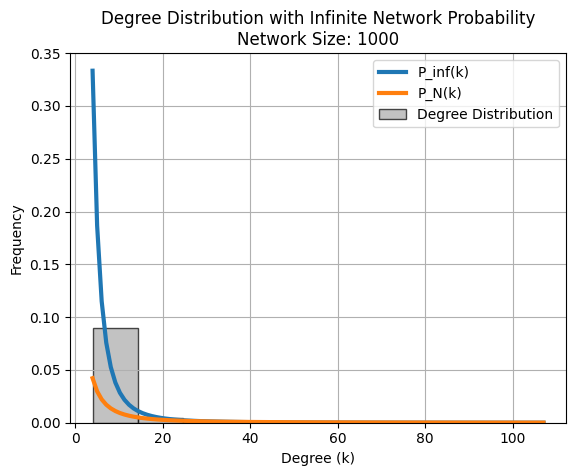

In [30]:
m = 4
N = 1000

np.random.seed(9)

# Compute Network for N = 10^6 nodes
Network = generate_BA(N, m)
k_list = create_degree_list(Network, m)
plot_probabilities(k_list, N, m)
plot_histogram(k_list, N, m)

## Part 3: 
*For m = 4, compute the average degree distribution PN (k) for BA networks with size
N = 50, 100, 200 and 500. Perform averages over a number of M = 10000 different
networks. For the averages, make a histogram accumulated the degrees of all the networks
generates and apply normalization at the end. Check the finite size corrections in Eq. (4)
by plotting, for the different values of N the Pest(k)/P∞(k) as a function of k, where
Pest(k) is the average degree distribution that you have estimated numerically*


As we can see, this method doesn't work that well due to an anomalous peak near higher degrees. To remedy this, we can approach the average with from a new approach.

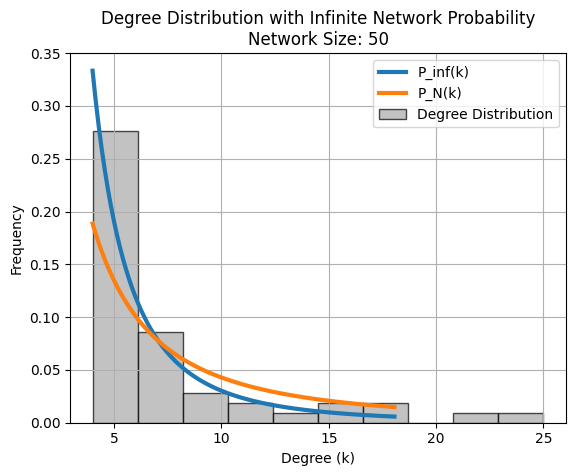

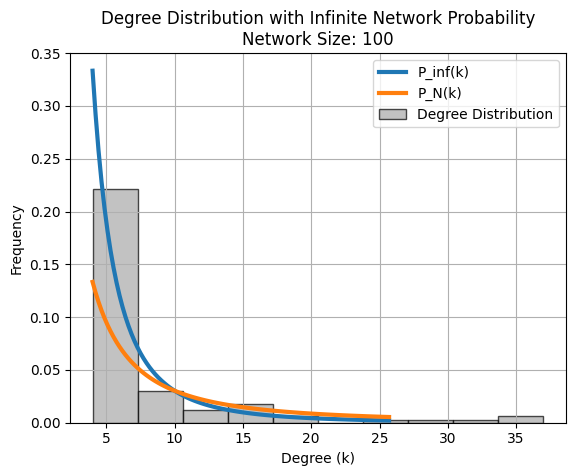

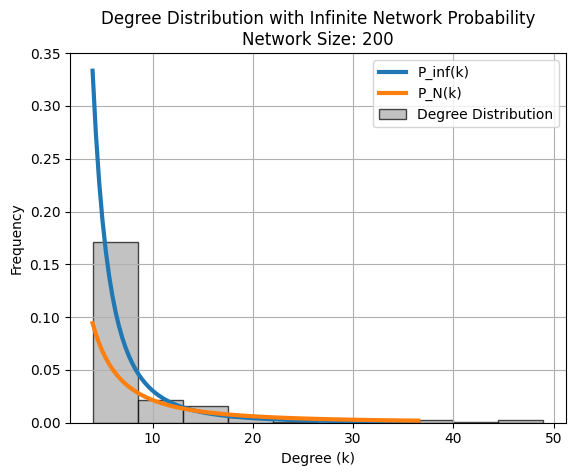

In [32]:
# For M different Networks
M = 100
# N_vals = [50, 100, 200, 500]
N_vals = [50, 100, 200]  # Quicker

for N in N_vals:

    k_list_avg = []
    for network in range(M):
        Network_i = generate_BA(N, m)
        k_list = create_degree_list(Network_i, m)
        k_list_avg.append(k_list)

    # Pad extra degree spaces with zero for accurate averaging
    max_length = max(len(k) for k in k_list_avg)
    k_list_avg = [k + [0] * (max_length - len(k)) for k in k_list_avg]

    k_list_avg = np.array(k_list_avg)
    k_list_avg = np.mean(k_list_avg, axis=0)

    # Convert back to list
    k_list_avg = k_list_avg.tolist()


    plot_probabilities(k_list_avg, N, m)
    plot_histogram(k_list, N, m)

### Histogram Bin Averaging Method:
In this method, we can take the summation of the individual bins after creating histograms for each network. This should eliminate our error.

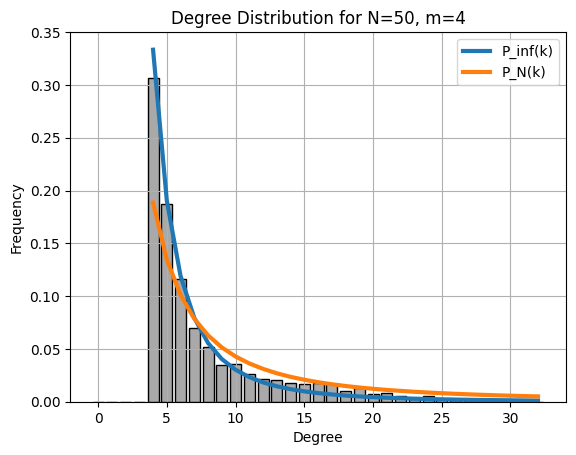

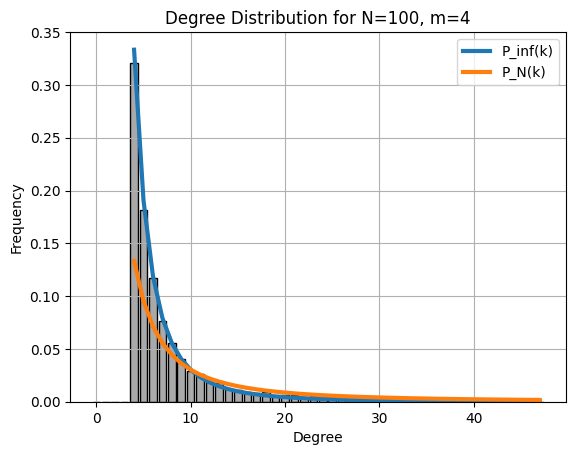

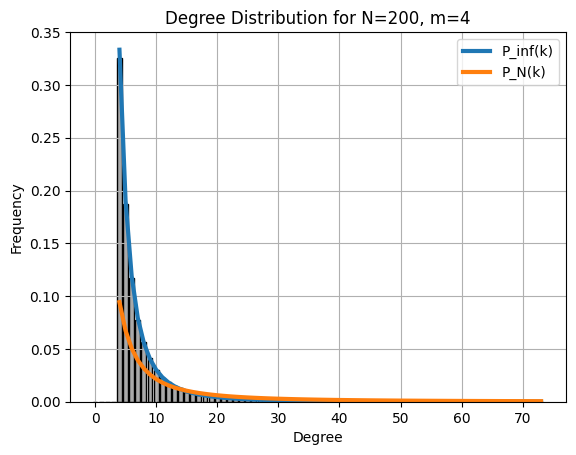

In [33]:
# For M different Networks
M = 100

for N in N_vals:

    hist_sum = None

    # Initialize Max Degree Value
    max_degree = 0

    for network in range(M):
        Network_i = generate_BA(N, m)
        k_list = create_degree_list(Network_i, m)

        # Keep track of max_degree encountered
        max_degree = max(max_degree, max(k_list))

    # Define consitent bins for np.histogram()
    bins = range(0, max_degree + 2)

    for network in range(M):
        Network_i = generate_BA(N, m)
        k_list = create_degree_list(Network_i, m)

        hist, _ = np.histogram(k_list, bins=bins) # Need to use consistent bins here

        if hist_sum is None:
            hist_sum = hist
        else:
            hist_sum += hist
            
    # Normalization
    hist_avg = hist_sum / M
    hist_avg = hist_avg / np.sum(hist_avg)

    # Plot the histograms
    plot_averaged_probabilities(hist_avg, bins, N, m)
    plot_averaged_histograms(hist_avg, N, m)



### Computing $P_{est} / P_{\infty}$ to compare results:

C:\Users\Jarvis\AppData\Local\Temp\ipykernel_52164\746563721.py:40: RuntimeWarning: invalid value encountered in divide
  correction = hist_avg / P_inf_vals  # Finite size correction


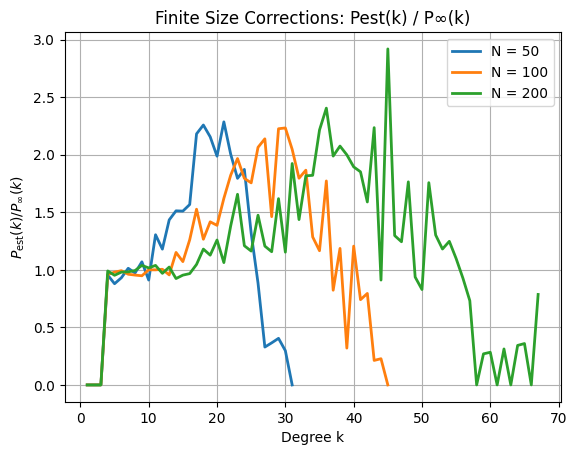

In [34]:
# Plot the Finite Size Correction   
plot_finite_size_correction(hist_avg, bins, N_vals, m, M)

## Part 4: Extra Point
*For a minimum degree m = 4, compute the average clustering coefficient 〈c〉N
for BA networks with size N = 25, 100, 200, 500, 1000, 5000 and 10000. Perform averages
over M = 25 different networks. Plot the average clustering coefficient as a function of
the network size*

In [ ]:
# Maybe Do This